In [5]:
import requests
import json

# for arxiv 

In [6]:
r = requests.post(
    'https://api.semanticscholar.org/graph/v1/paper/batch',
    params={'fields': 'referenceCount,citationCount,title'},
    json={"ids": ["649def34f8be52c8b66281af98ae884c09aef38b", "ARXIV:2106.15928"]} # gets specific id
)

In [7]:
print(json.dumps(r.json(), indent=2))

[
  {
    "paperId": "649def34f8be52c8b66281af98ae884c09aef38b",
    "title": "Construction of the Literature Graph in Semantic Scholar",
    "referenceCount": 26,
    "citationCount": 383
  },
  {
    "paperId": "f712fab0d58ae6492e3cdfc1933dae103ec12d5d",
    "title": "Reinfection and low cross-immunity as drivers of epidemic resurgence under high seroprevalence: a model-based approach with application to Amazonas, Brazil",
    "referenceCount": 13,
    "citationCount": 0
  }
]


Resolving paper identifier: Variational Autoencoders
Found paper: An Introduction to Variational Autoencoders
  [OPEN ACCESS] PDF available at: https://arxiv.org/pdf/1906.02691
Added seed paper: An Introduction to Variational Autoencoders
Processing citations for paper: 329b84a919bfd1771be5bd14fa81e7b3f74cc961
Found 10 citations to process
Added paper 2/100: Deep evolving semi-supervised anomaly detection...
Processing citations for paper: 3c2b6f5498539cae79f6ba35952c68e5964f799a
No citations found for paper: 3c2b6f5498539cae79f6ba35952c68e5964f799a
Added paper 3/100: Visible Light Communication Channel Modeling Using...
Processing citations for paper: 9419c33662c4a2f793db43a5a70e5106bb51f703
No citations found for paper: 9419c33662c4a2f793db43a5a70e5106bb51f703
  [OPEN ACCESS] PDF available at: http://arxiv.org/pdf/2411.07055
Added paper 4/100: Reconstruction of neuromorphic dynamics from a sin...
Processing citations for paper: 5657b36c83506db3bdb62a63814b78b5e12f7c1c
No citations fo

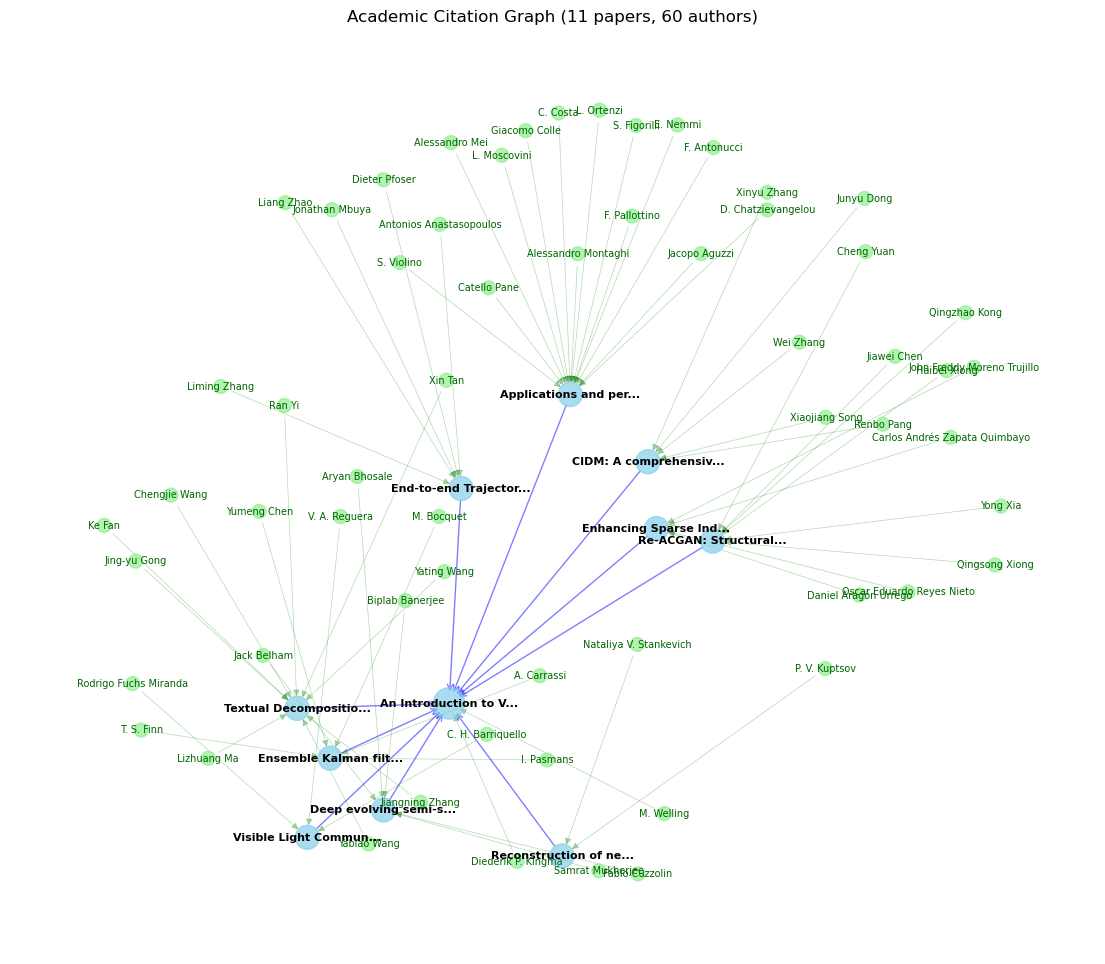

In [21]:
import requests
import networkx as nx
import json
import time
from datetime import datetime
from typing import Dict, List, Optional, Set, Tuple, Union
import matplotlib.pyplot as plt
from collections import deque

class CitationGraphBuilder:
    def __init__(self, api_key: Optional[str] = None, max_papers: int = 20):
        """
        Initialize Citation Graph Builder
        
        Args:
            api_key: Optional API key for Semantic Scholar
            max_papers: Maximum number of papers to include in the graph
        """
        self.base_url = "https://api.semanticscholar.org/graph/v1"
        self.headers = {"x-api-key": api_key} if api_key else {}
        self.graph = nx.DiGraph()
        self.last_request_time = datetime.now()
        self.request_interval = 0.2 if api_key else 3.0  # More conservative rate limit without API key
        self.max_papers = max_papers
        self.paper_count = 0
        self.paper_cache = {}  # Cache paper data to reduce API calls
        self.processed_papers = set()  # Track papers we've already processed
        
    def _wait_for_rate_limit(self):
        """Ensure we don't exceed API rate limits"""
        now = datetime.now()
        elapsed = now - self.last_request_time
        if elapsed.total_seconds() < self.request_interval:
            time.sleep(self.request_interval - elapsed.total_seconds())
        self.last_request_time = datetime.now()

    def _make_request(self, endpoint: str, params: Dict = None, max_retries: int = 3) -> Dict:
        """
        Make an API request with proper error handling and retries
        
        Args:
            endpoint: API endpoint
            params: Query parameters
            max_retries: Maximum number of retry attempts
        
        Returns:
            API response as dictionary or None on failure
        """
        if params is None:
            params = {}
            
        for attempt in range(max_retries):
            self._wait_for_rate_limit()
            
            try:
                response = requests.get(
                    f"{self.base_url}/{endpoint}", 
                    headers=self.headers,
                    params=params,
                    timeout=30  # Add timeout
                )
                
                if response.status_code == 200:
                    return response.json()
                elif response.status_code == 429:  # Rate limit
                    wait_time = min(30, 2 ** (attempt + 1))  # Exponential backoff with cap
                    print(f"Rate limit hit, waiting {wait_time} seconds...")
                    time.sleep(wait_time)
                    continue
                elif response.status_code == 404:
                    print(f"Resource not found: {endpoint}")
                    return None
                else:
                    print(f"Error making request: {response.status_code} - {endpoint}")
                    print(f"Response: {response.text[:200]}...")  # Show only start of response
                    if attempt < max_retries - 1:
                        time.sleep(2 ** attempt)
                        continue
                    break
                    
            except requests.exceptions.RequestException as e:
                print(f"Request failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt)
                    continue
                break
                
        return None

    def _clean_attributes(self, attrs: Dict) -> Dict:
        """Convert complex objects to strings for NetworkX compatibility"""
        if not attrs:
            return {}
            
        cleaned = {}
        for k, v in attrs.items():
            if v is None:
                cleaned[k] = ""
            elif isinstance(v, (list, dict)):
                try:
                    cleaned[k] = json.dumps(v)
                except (TypeError, ValueError):
                    # If we can't serialize to JSON, convert to string
                    cleaned[k] = str(v)
            elif isinstance(v, (str, int, float, bool)):
                cleaned[k] = v
            else:
                cleaned[k] = str(v)
        return cleaned

    def _get_paper_details(self, paper_id: str) -> Dict:
        """
        Get detailed information about a paper
        
        Args:
            paper_id: Paper identifier
            
        Returns:
            Paper details or None if not found
        """
        # Check cache first
        if paper_id in self.paper_cache:
            return self.paper_cache[paper_id]
        
        # Request with all fields we need for rich metadata, including open access information
        paper = self._make_request(f"paper/{paper_id}", {
            "fields": "paperId,title,abstract,authors,venue,year,citationCount,referenceCount," +
                      "fieldsOfStudy,tldr,url,isOpenAccess,openAccessPdf,externalIds," +
                      "publicationDate,journal,publicationTypes,publicationVenue"
        })
        
        # Validate the response
        if paper and isinstance(paper, dict) and "paperId" in paper:
            self.paper_cache[paper_id] = paper
            return paper
        else:
            print(f"Warning: Invalid paper data returned for ID: {paper_id}")
            return None

    def _resolve_paper_id(self, paper_identifier: str) -> Optional[str]:
        """
        Resolve paper identifier to paper ID
        
        Args:
            paper_identifier: DOI, URL, or title
            
        Returns:
            Paper ID or None if not found
        """
        print(f"Resolving paper identifier: {paper_identifier}")
        
        # Check if already a paper ID format or has a prefix
        if paper_identifier.startswith(('DOI:', 'URL:', 'ARXIV:', 'PMID:')):
            return paper_identifier
            
        # Try to search by title
        search_result = self._make_request("paper/search", {
            "query": paper_identifier,
            "limit": 1,
            "fields": "paperId,title"
        })
        
        if search_result and "data" in search_result and search_result["data"] and len(search_result["data"]) > 0:
            paper = search_result["data"][0]
            if "paperId" in paper:
                print(f"Found paper: {paper.get('title')}")
                return paper.get("paperId")
            else:
                print(f"Warning: Paper found but missing paperId in search result")
        else:
            print(f"No papers found matching: {paper_identifier}")
        
        return None

    def add_paper_node(self, paper: Dict) -> bool:
        """
        Add a paper node to the graph with all relevant attributes
        
        Args:
            paper: Paper data dictionary
            
        Returns:
            True if added, False if skipped
        """
        if not paper or "paperId" not in paper:
            print("Warning: Invalid paper data - missing paperId")
            return False
            
        # Skip if we've reached our max papers or already added this paper
        if paper["paperId"] in self.graph:
            print(f"Paper already in graph: {paper['paperId']}")
            return False
            
        if self.paper_count >= self.max_papers:
            print("Maximum paper count reached")
            return False
            
        # Extract paper attributes
        paper_attrs = {
            "type": "paper",
            "title": paper.get("title", ""),
            "abstract": paper.get("abstract", ""),
            "year": paper.get("year", ""),
            "venue": paper.get("venue", ""),
            "url": paper.get("url", ""),
            "citation_count": paper.get("citationCount", 0),
            "reference_count": paper.get("referenceCount", 0),
            "fields_of_study": paper.get("fieldsOfStudy", []),
            "is_open_access": paper.get("isOpenAccess", False),
            "tldr": paper.get("tldr", {}).get("text", "") if paper.get("tldr") else ""
        }
        
        # Add open access PDF information if available
        if paper.get("isOpenAccess", False) and paper.get("openAccessPdf"):
            paper_attrs["open_access_pdf_url"] = paper["openAccessPdf"].get("url", "")
            paper_attrs["open_access_status"] = paper["openAccessPdf"].get("status", "")
            
            # Log availability of open access PDF
            print(f"  [OPEN ACCESS] PDF available at: {paper_attrs['open_access_pdf_url']}")
        
        # Add external IDs if available
        if paper.get("externalIds"):
            for id_type, id_value in paper["externalIds"].items():
                paper_attrs[f"external_id_{id_type.lower()}"] = id_value
        
        # Add publication date if available
        if paper.get("publicationDate"):
            paper_attrs["publication_date"] = paper.get("publicationDate")
            
        # Add journal information if available
        if paper.get("journal"):
            journal = paper["journal"]
            if journal.get("name"):
                paper_attrs["journal_name"] = journal.get("name")
            if journal.get("volume"):
                paper_attrs["journal_volume"] = journal.get("volume")
            if journal.get("pages"):
                paper_attrs["journal_pages"] = journal.get("pages")
        
        self.graph.add_node(paper["paperId"], **self._clean_attributes(paper_attrs))
        self.paper_count += 1
        
        # Add authors
        if "authors" in paper and paper["authors"]:
            for author in paper["authors"]:
                if "authorId" not in author:
                    continue
                    
                author_attrs = {
                    "type": "author",
                    "name": author.get("name", "")
                }
                
                self.graph.add_node(author["authorId"], **self._clean_attributes(author_attrs))
                self.graph.add_edge(author["authorId"], paper["paperId"], type="authored")
                
        return True

    def build_citation_graph(self, seed_paper_id: str, max_citations_per_paper: int = 3) -> nx.DiGraph:
        """
        Build a citation graph recursively starting from a seed paper
        
        Args:
            seed_paper_id: Paper ID or title to start with
            max_citations_per_paper: Maximum number of citations to include per paper
            
        Returns:
            NetworkX DiGraph object
        """
        # Resolve the paper ID if needed
        paper_id = self._resolve_paper_id(seed_paper_id)
        if not paper_id:
            print(f"Could not resolve paper: {seed_paper_id}")
            return self.graph
            
        # Get paper details
        paper = self._get_paper_details(paper_id)
        if not paper or "paperId" not in paper:
            print(f"Could not retrieve paper details: {paper_id}")
            return self.graph
            
        # Add seed paper
        if not self.add_paper_node(paper):
            return self.graph
            
        print(f"Added seed paper: {paper.get('title')}")
        
        # Start recursive traversal
        self._process_paper_citations(paper["paperId"], max_citations_per_paper)
        
        return self.graph
    
    def _process_paper_citations(self, paper_id: str, max_citations_per_paper: int, depth: int = 0):
        """
        Recursively process citations for a paper
        
        Args:
            paper_id: ID of the paper to process
            max_citations_per_paper: Maximum citations to include per paper
            depth: Current recursion depth
        """
        # Stop if we've reached the maximum number of papers
        if self.paper_count >= self.max_papers:
            return
            
        # Get citations for this paper
        print(f"Processing citations for paper: {paper_id}")
        citations_data = self._make_request(f"paper/{paper_id}/citations", {
            "fields": "paperId,citingPaper.paperId,citingPaper.title,citingPaper.abstract,citingPaper.year," +
                      "citingPaper.citationCount,citingPaper.fieldsOfStudy,citingPaper.authors,contexts,isInfluential",
            "limit": 100
        })
        
        if not citations_data or "data" not in citations_data or not citations_data["data"]:
            print(f"No citations found for paper: {paper_id}")
            return
            
        # Sort citations by influence and citation count
        sorted_citations = sorted(
            citations_data["data"],
            key=lambda x: (
                x.get("isInfluential", False),  # Influential papers first
                x.get("citingPaper", {}).get("citationCount", 0),  # Then by citation count
            ),
            reverse=True
        )
        
        # Take only the top N citations
        top_citations = sorted_citations[:max_citations_per_paper]
        
        print(f"Found {len(top_citations)} citations to process")
        
        # Process each citation
        for citation in top_citations:
            # Skip if we've reached max papers
            if self.paper_count >= self.max_papers:
                print("Reached maximum number of papers")
                return
                
            citing_paper = citation.get("citingPaper", {})
            if not citing_paper or "paperId" not in citing_paper:
                print("Skipping citation with missing paperId")
                continue
                
            citing_paper_id = citing_paper["paperId"]
            
            # Skip if already in graph
            if citing_paper_id in self.graph:
                print(f"Paper already in graph: {citing_paper_id}")
                
                # Add citation edge if it doesn't exist
                if not self.graph.has_edge(citing_paper_id, paper_id):
                    edge_attrs = {
                        "type": "cites",
                        "contexts": citation.get("contexts", []),
                        "is_influential": citation.get("isInfluential", False)
                    }
                    self.graph.add_edge(citing_paper_id, paper_id, **self._clean_attributes(edge_attrs))
                    
                continue
                
            # Get full paper details
            citing_paper_details = self._get_paper_details(citing_paper_id)
            if not citing_paper_details:
                print(f"Could not retrieve details for paper: {citing_paper_id}")
                continue
                
            # Add to graph
            if self.add_paper_node(citing_paper_details):
                print(f"Added paper {self.paper_count}/{self.max_papers}: {citing_paper_details.get('title', 'Unknown')[:50]}...")
                
                # Add citation edge
                edge_attrs = {
                    "type": "cites",
                    "contexts": citation.get("contexts", []),
                    "is_influential": citation.get("isInfluential", False)
                }
                self.graph.add_edge(citing_paper_id, paper_id, **self._clean_attributes(edge_attrs))
                
                # Recursively process this paper's citations
                self._process_paper_citations(citing_paper_id, max_citations_per_paper, depth + 1)

    def export_to_file(self, filename: str, format: str = "json"):
        """
        Export the knowledge graph to a file
        
        Args:
            filename: Output file path
            format: Export format ('json', 'graphml', or 'gexf')
        """
        print(f"\nExporting graph with {self.graph.number_of_nodes()} nodes and {self.graph.number_of_edges()} edges")
        
        if format == "json":
            data = {
                "nodes": [{"id": n, **self.graph.nodes[n]} for n in self.graph.nodes()],
                "edges": [{"source": u, "target": v, **self.graph.edges[u, v]} 
                         for u, v in self.graph.edges()]
            }
            
            # Count node types
            paper_nodes = [n for n, attrs in self.graph.nodes(data=True) if attrs.get('type') == 'paper']
            author_nodes = [n for n, attrs in self.graph.nodes(data=True) if attrs.get('type') == 'author']
            print(f"Graph contains {len(paper_nodes)} papers and {len(author_nodes)} authors")
            
            with open(filename, 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
        
        elif format == "graphml":
            nx.write_graphml(self.graph, filename)
            
        elif format == "gexf":
            nx.write_gexf(self.graph, filename)
            
        print(f"Graph exported to {filename}")

    def visualize(self, output_file: str = None, show_plot: bool = True):
        """
        Visualize the citation graph
        
        Args:
            output_file: Path to save visualization image
            show_plot: Whether to display the plot
        """
        # Create figure
        plt.figure(figsize=(14, 12))
        
        # Get node types
        paper_nodes = [n for n, attr in self.graph.nodes(data=True) if attr.get('type') == 'paper']
        author_nodes = [n for n, attr in self.graph.nodes(data=True) if attr.get('type') == 'author']
        
        # Size nodes by citation count for papers
        paper_sizes = []
        for node in paper_nodes:
            citation_count = self.graph.nodes[node].get('citation_count', 0)
            try:
                size = 300 + float(citation_count) * 0.1
                size = min(2000, size)  # Cap at maximum size
            except (ValueError, TypeError):
                size = 300
            paper_sizes.append(size)
        
        # Fixed size for authors
        author_sizes = [100] * len(author_nodes)
        
        # Use spring layout
        pos = nx.spring_layout(self.graph, k=0.3, iterations=50)
        
        # Draw papers
        nx.draw_networkx_nodes(
            self.graph, pos,
            nodelist=paper_nodes,
            node_color='skyblue',
            node_size=paper_sizes,
            alpha=0.7
        )
        
        # Draw authors
        nx.draw_networkx_nodes(
            self.graph, pos,
            nodelist=author_nodes,
            node_color='lightgreen',
            node_size=author_sizes,
            alpha=0.7
        )
        
        # Draw citation edges
        citation_edges = [(u, v) for u, v, attr in self.graph.edges(data=True) if attr.get('type') == 'cites']
        nx.draw_networkx_edges(
            self.graph, pos,
            edgelist=citation_edges,
            width=1.0,
            alpha=0.5,
            edge_color='blue',
            arrows=True,
            arrowstyle='->',
            arrowsize=10
        )
        
        # Draw authorship edges
        authorship_edges = [(u, v) for u, v, attr in self.graph.edges(data=True) if attr.get('type') == 'authored']
        nx.draw_networkx_edges(
            self.graph, pos,
            edgelist=authorship_edges,
            width=0.5,
            alpha=0.3,
            edge_color='green',
            arrows=True
        )
        
        # Add paper labels
        paper_labels = {node: f"{self.graph.nodes[node].get('title', '')[:20]}..." for node in paper_nodes}
        nx.draw_networkx_labels(
            self.graph, pos,
            labels=paper_labels,
            font_size=8,
            font_weight='bold'
        )
        
        # Add minimal author labels
        author_labels = {node: self.graph.nodes[node].get('name', '') for node in author_nodes}
        nx.draw_networkx_labels(
            self.graph, pos,
            labels=author_labels,
            font_size=7,
            font_color='darkgreen'
        )
        
        plt.title(f"Academic Citation Graph ({len(paper_nodes)} papers, {len(author_nodes)} authors)")
        plt.axis('off')
        
        if output_file:
            plt.savefig(output_file, format='png', dpi=300, bbox_inches='tight')
            print(f"Visualization saved to {output_file}")
            
        if show_plot:
            plt.show()

# Example usage
if __name__ == "__main__":
    # Get API key (optional)
    api_key = None  # Replace with your API key if you have one
    
    # Initialize graph builder
    graph_builder = CitationGraphBuilder(api_key=api_key, max_papers=100)
    
    # Set a more conservative request interval if you don't have an API key
    if not api_key:
        graph_builder.request_interval = 4.0
    
    # Build citation graph
    paper_title = "Variational Autoencoders"  # Famous Transformer paper
    graph = graph_builder.build_citation_graph(
        paper_title,
        max_citations_per_paper= 10# Limit to 3 citations per paper for faster building
    )
    
    # Export to file
    graph_builder.export_to_file("citation_graph.json")
    
    # Visualize
    graph_builder.visualize("citation_graph.png")

In [22]:
# seems to have a hard time building on citaitons

Resolving paper identifier: Attention Is All You Need
Found paper: Attention is All you Need
Added seed paper: Attention is All you Need

Processing paper: 204e3073870fae3d05bcbc2f6a8e263d9b72e776 at depth 0
Processing 5 citations for paper: 204e3073870fae3d05bcbc2f6a8e263d9b72e776
Rate limit hit, waiting 2 seconds...
Rate limit hit, waiting 4 seconds...
Rate limit hit, waiting 8 seconds...
Could not retrieve details for paper: eba122f6ffcd430037ea753f47385126caebf5b1
Rate limit hit, waiting 2 seconds...
Added paper 2/50: Direction-guided network for retinal vessel segmen...
Added paper 3/50: LAMFFNet: Lightweight Adaptive Multi-layer Feature...
Rate limit hit, waiting 2 seconds...
Added paper 4/50: Advances in attention mechanisms for medical image...
Rate limit hit, waiting 2 seconds...
Added paper 5/50: Understandable time frame-based biosignal processi...
Processing 5 references for paper: 204e3073870fae3d05bcbc2f6a8e263d9b72e776
Added paper 6/50: Convolutional Sequence to Sequence

/Users/pranavsingh/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Graph contains 4 citation cycles
Graph exported to cyclic_citation_graph.json
Found 4 cycles in the graph
Visualization saved to cyclic_citation_graph.png


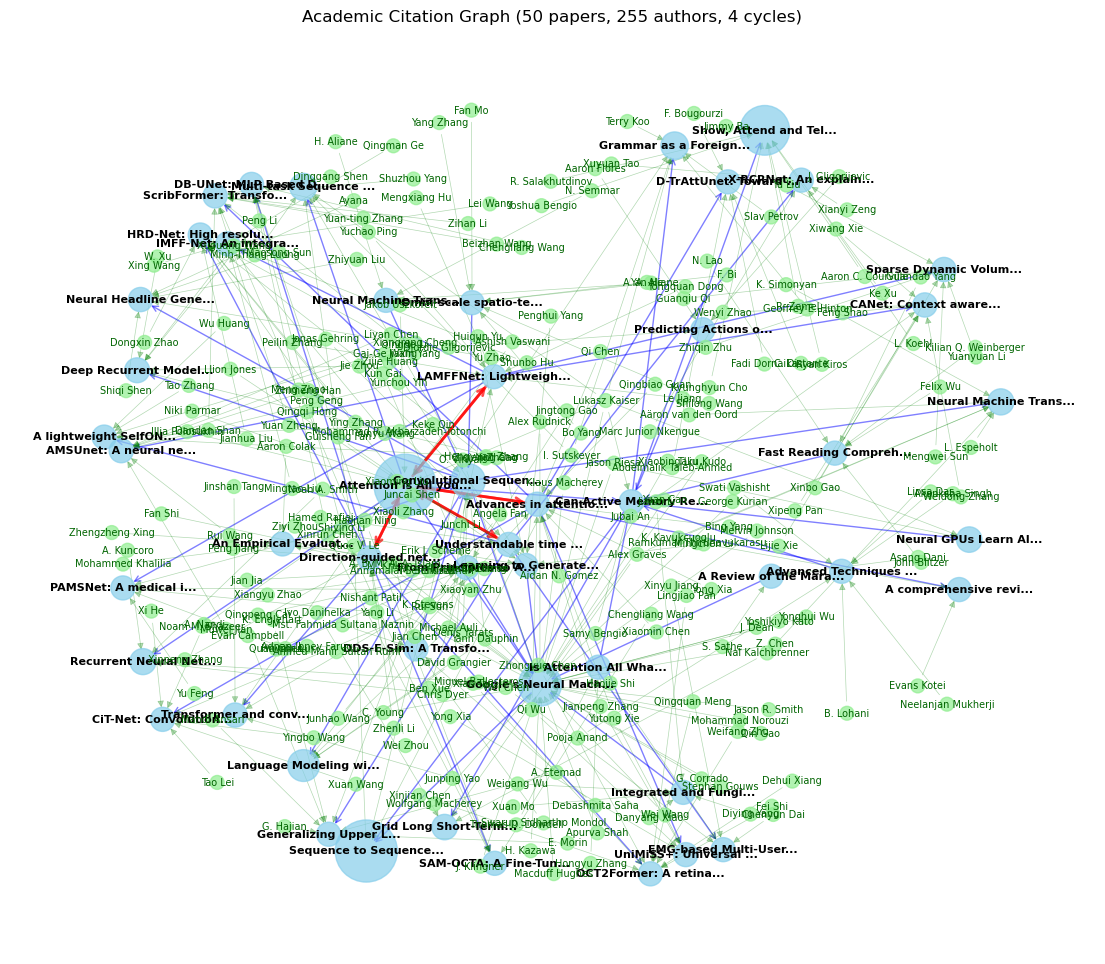

In [23]:
import requests
import networkx as nx
import json
import time
from datetime import datetime
from typing import Dict, List, Optional, Set, Tuple, Union
import matplotlib.pyplot as plt
from collections import deque

class EnhancedCitationGraphBuilder:
    def __init__(self, api_key: Optional[str] = None, max_papers: int = 20):
        """
        Initialize Enhanced Citation Graph Builder with bidirectional exploration
        
        Args:
            api_key: Optional API key for Semantic Scholar
            max_papers: Maximum number of papers to include in the graph
        """
        self.base_url = "https://api.semanticscholar.org/graph/v1"
        self.headers = {"x-api-key": api_key} if api_key else {}
        self.graph = nx.DiGraph()
        self.last_request_time = datetime.now()
        self.request_interval = 0.2 if api_key else 3.0  # More conservative rate limit without API key
        self.max_papers = max_papers
        self.paper_count = 0
        self.paper_cache = {}  # Cache paper data to reduce API calls
        
        # Keep track of papers we've already processed to avoid redundant API calls
        self.processed_papers = set()  
        
        # Keep track of papers we've already queued to avoid redundant processing
        self.queued_papers = set()
        
        # Track paper connections for finding cycles
        self.paper_connections = {}  # paper_id -> set of connected papers
        
    def _wait_for_rate_limit(self):
        """Ensure we don't exceed API rate limits"""
        now = datetime.now()
        elapsed = now - self.last_request_time
        if elapsed.total_seconds() < self.request_interval:
            time.sleep(self.request_interval - elapsed.total_seconds())
        self.last_request_time = datetime.now()

    def _make_request(self, endpoint: str, params: Dict = None, max_retries: int = 3) -> Dict:
        """Make an API request with proper error handling and retries"""
        if params is None:
            params = {}
            
        for attempt in range(max_retries):
            self._wait_for_rate_limit()
            
            try:
                response = requests.get(
                    f"{self.base_url}/{endpoint}", 
                    headers=self.headers,
                    params=params,
                    timeout=30
                )
                
                if response.status_code == 200:
                    return response.json()
                elif response.status_code == 429:  # Rate limit
                    wait_time = min(30, 2 ** (attempt + 1))
                    print(f"Rate limit hit, waiting {wait_time} seconds...")
                    time.sleep(wait_time)
                    continue
                elif response.status_code == 404:
                    print(f"Resource not found: {endpoint}")
                    return None
                else:
                    print(f"Error making request: {response.status_code} - {endpoint}")
                    print(f"Response: {response.text[:200]}...")
                    if attempt < max_retries - 1:
                        time.sleep(2 ** attempt)
                        continue
                    break
                    
            except requests.exceptions.RequestException as e:
                print(f"Request failed: {e}")
                if attempt < max_retries - 1:
                    time.sleep(2 ** attempt)
                    continue
                break
                
        return None

    def _clean_attributes(self, attrs: Dict) -> Dict:
        """Convert complex objects to strings for NetworkX compatibility"""
        if not attrs:
            return {}
            
        cleaned = {}
        for k, v in attrs.items():
            if v is None:
                cleaned[k] = ""
            elif isinstance(v, (list, dict)):
                try:
                    cleaned[k] = json.dumps(v)
                except (TypeError, ValueError):
                    cleaned[k] = str(v)
            elif isinstance(v, (str, int, float, bool)):
                cleaned[k] = v
            else:
                cleaned[k] = str(v)
        return cleaned

    def _get_paper_details(self, paper_id: str) -> Dict:
        """Get detailed information about a paper"""
        # Check cache first
        if paper_id in self.paper_cache:
            return self.paper_cache[paper_id]
        
        paper = self._make_request(f"paper/{paper_id}", {
            "fields": "paperId,title,abstract,authors,venue,year,citationCount,referenceCount," +
                      "fieldsOfStudy,tldr,url,isOpenAccess,openAccessPdf,externalIds," +
                      "publicationDate,journal,publicationTypes,publicationVenue"
        })
        
        if paper and isinstance(paper, dict) and "paperId" in paper:
            self.paper_cache[paper_id] = paper
            return paper
        else:
            print(f"Warning: Invalid paper data returned for ID: {paper_id}")
            return None

    def _resolve_paper_id(self, paper_identifier: str) -> Optional[str]:
        """Resolve paper identifier to paper ID"""
        print(f"Resolving paper identifier: {paper_identifier}")
        
        # Check if already a paper ID format or has a prefix
        if paper_identifier.startswith(('DOI:', 'URL:', 'ARXIV:', 'PMID:')):
            return paper_identifier
            
        # Try to search by title
        search_result = self._make_request("paper/search", {
            "query": paper_identifier,
            "limit": 1,
            "fields": "paperId,title"
        })
        
        if search_result and "data" in search_result and search_result["data"] and len(search_result["data"]) > 0:
            paper = search_result["data"][0]
            if "paperId" in paper:
                print(f"Found paper: {paper.get('title')}")
                return paper.get("paperId")
            else:
                print(f"Warning: Paper found but missing paperId in search result")
        else:
            print(f"No papers found matching: {paper_identifier}")
        
        return None

    def add_paper_node(self, paper: Dict) -> bool:
        """Add a paper node to the graph with all relevant attributes"""
        if paper is None:
            print("Warning: Paper is None, skipping add_paper_node")
            return False
            
        if not paper or "paperId" not in paper:
            print("Warning: Invalid paper data - missing paperId")
            return False
            
        # Skip if we've reached our max papers or already added this paper
        if paper["paperId"] in self.graph:
            print(f"Paper already in graph: {paper['paperId']}")
            return False
            
        if self.paper_count >= self.max_papers:
            print("Maximum paper count reached")
            return False
            
        # Extract paper attributes
        paper_attrs = {
            "type": "paper",
            "title": paper.get("title", ""),
            "abstract": paper.get("abstract", ""),
            "year": paper.get("year", ""),
            "venue": paper.get("venue", ""),
            "url": paper.get("url", ""),
            "citation_count": paper.get("citationCount", 0),
            "reference_count": paper.get("referenceCount", 0),
            "fields_of_study": paper.get("fieldsOfStudy", []),
            "is_open_access": paper.get("isOpenAccess", False),
            "tldr": paper.get("tldr", {}).get("text", "") if paper.get("tldr") else ""
        }
        
        # Add open access PDF information if available
        if paper.get("isOpenAccess", False) and paper.get("openAccessPdf"):
            paper_attrs["open_access_pdf_url"] = paper["openAccessPdf"].get("url", "")
            paper_attrs["open_access_status"] = paper["openAccessPdf"].get("status", "")
            
            # Log availability of open access PDF
            print(f"  [OPEN ACCESS] PDF available at: {paper_attrs['open_access_pdf_url']}")
        
        # Add external IDs if available
        if paper.get("externalIds"):
            for id_type, id_value in paper["externalIds"].items():
                paper_attrs[f"external_id_{id_type.lower()}"] = id_value
        
        # Add to graph
        self.graph.add_node(paper["paperId"], **self._clean_attributes(paper_attrs))
        self.paper_count += 1
        
        # Add authors
        if "authors" in paper and paper["authors"]:
            for author in paper["authors"]:
                if "authorId" not in author:
                    continue
                    
                author_attrs = {
                    "type": "author",
                    "name": author.get("name", "")
                }
                
                self.graph.add_node(author["authorId"], **self._clean_attributes(author_attrs))
                self.graph.add_edge(author["authorId"], paper["paperId"], type="authored")
                
        return True

    def _get_paper_citations(self, paper_id: str, limit: int = 100) -> List[Dict]:
        """Get papers that cite this paper"""
        citations_data = self._make_request(f"paper/{paper_id}/citations", {
            "fields": "paperId,citingPaper.paperId,citingPaper.title,citingPaper.abstract,citingPaper.year," +
                      "citingPaper.citationCount,citingPaper.fieldsOfStudy,citingPaper.authors,contexts,isInfluential",
            "limit": limit
        })
        
        if not citations_data or "data" not in citations_data or not citations_data["data"]:
            print(f"No citations found for paper: {paper_id}")
            return []
            
        return citations_data["data"]

    def _get_paper_references(self, paper_id: str, limit: int = 100) -> List[Dict]:
        """Get papers that this paper cites (its references)"""
        references_data = self._make_request(f"paper/{paper_id}/references", {
            "fields": "paperId,citedPaper.paperId,citedPaper.title,citedPaper.abstract,citedPaper.year," +
                      "citedPaper.citationCount,citedPaper.fieldsOfStudy,citedPaper.authors,contexts,isInfluential",
            "limit": limit
        })
        
        if not references_data or "data" not in references_data or not references_data["data"]:
            print(f"No references found for paper: {paper_id}")
            return []
            
        return references_data["data"]

    def build_cyclic_citation_graph(self, seed_paper_id: str, max_per_direction: int = 3) -> nx.DiGraph:
        """
        Build a citation graph with cycles by exploring both citations and references
        
        Args:
            seed_paper_id: Paper ID or title to start with
            max_per_direction: Maximum number of citations/references to include per paper
            
        Returns:
            NetworkX DiGraph object
        """
        # Skip if seed_paper_id is None
        if seed_paper_id is None:
            print("Skipping build_cyclic_citation_graph: seed_paper_id is None")
            return self.graph
            
        # Resolve the paper ID if needed
        seed_paper_id = self._resolve_paper_id(seed_paper_id)
        if not seed_paper_id:
            print(f"Could not resolve seed paper")
            return self.graph
            
        # Get paper details
        seed_paper = self._get_paper_details(seed_paper_id)
        if not seed_paper or "paperId" not in seed_paper:
            print(f"Could not retrieve seed paper details")
            return self.graph
            
        # Add seed paper
        self.add_paper_node(seed_paper)
        print(f"Added seed paper: {seed_paper.get('title')}")
        
        # Initialize BFS queue for processing papers in a more networked way
        paper_queue = deque([(seed_paper_id, 0)])  # (paper_id, depth)
        self.queued_papers.add(seed_paper_id)
        
        # Start BFS traversal
                    while paper_queue and self.paper_count < self.max_papers:
            current_paper_id, depth = paper_queue.popleft()
            
            # Skip if current_paper_id is None
            if current_paper_id is None:
                print("Skipping iteration: current_paper_id is None")
                continue
                
            if current_paper_id in self.processed_papers:
                continue
                
            print(f"\nProcessing paper: {current_paper_id} at depth {depth}")
            
            # Get paper details if not in cache
            if current_paper_id not in self.paper_cache:
                paper = self._get_paper_details(current_paper_id)
                if not paper:
                    print(f"Could not retrieve paper details for {current_paper_id}, skipping")
                    continue
            
            # Mark as processed
            self.processed_papers.add(current_paper_id)
            
            # 1. Process citations (papers that cite this paper)
            self._process_connected_papers(
                current_paper_id, 
                self._get_paper_citations(current_paper_id), 
                "citations",
                max_per_direction,
                paper_queue
            )
            
            # 2. Process references (papers this paper cites)
            self._process_connected_papers(
                current_paper_id, 
                self._get_paper_references(current_paper_id), 
                "references",
                max_per_direction,
                paper_queue
            )
            
            # 3. Look for potential cycles by connecting papers already in the graph
            self._find_potential_cycles(current_paper_id)
            
        return self.graph

    def _process_connected_papers(self, source_paper_id: str, connected_papers: List[Dict], 
                                connection_type: str, max_count: int, paper_queue: deque):
        """
        Process papers connected to the source paper (either citations or references)
        
        Args:
            source_paper_id: ID of the source paper
            connected_papers: List of connected papers data
            connection_type: Either "citations" or "references"
            max_count: Maximum number of papers to process
            paper_queue: Queue for BFS traversal
        """
        # Skip if source_paper_id is None or connected_papers is None
        if source_paper_id is None or connected_papers is None:
            print("Skipping process_connected_papers: source_paper_id or connected_papers is None")
            return
        # Sort papers by influence and citation count
        if connected_papers:
            if connection_type == "citations":
                paper_field = "citingPaper"
                edge_direction = (lambda citing, cited: (citing, cited))  # citing paper to cited paper
            else:  # references
                paper_field = "citedPaper"
                edge_direction = (lambda citing, cited: (citing, cited))  # citing paper to cited paper
                
            # Sort by influence and citation count
            sorted_papers = sorted(
                connected_papers,
                key=lambda x: (
                    x.get("isInfluential", False),
                    x.get(paper_field, {}).get("citationCount", 0)
                ),
                reverse=True
            )
            
            # Take only the top N papers
            top_papers = sorted_papers[:max_count]
            
            print(f"Processing {len(top_papers)} {connection_type} for paper: {source_paper_id}")
            
            # Process each connected paper
            for paper_data in top_papers:
                connected_paper = paper_data.get(paper_field, {})
                if not connected_paper or "paperId" not in connected_paper:
                    print("Skipping connected paper with missing paperId")
                    continue
                    
                connected_paper_id = connected_paper["paperId"]
                
                # Add edge based on connection type
                if connection_type == "citations":
                    # Citation edge: citing paper -> cited paper
                    source, target = connected_paper_id, source_paper_id
                else:  # references
                    # Reference edge: citing paper -> cited paper
                    source, target = source_paper_id, connected_paper_id
                
                # Add or update edge
                if self.graph.has_node(source) and self.graph.has_node(target):
                    # If both nodes exist, just add/update the edge
                    edge_attrs = {
                        "type": "cites",
                        "contexts": paper_data.get("contexts", []),
                        "is_influential": paper_data.get("isInfluential", False)
                    }
                    self.graph.add_edge(source, target, **self._clean_attributes(edge_attrs))
                
                elif not self.graph.has_node(connected_paper_id):
                    # If the connected paper node doesn't exist yet, add it
                    if self.paper_count < self.max_papers:
                        # Get full paper details
                        connected_paper_details = self._get_paper_details(connected_paper_id)
                        if not connected_paper_details:
                            print(f"Could not retrieve details for paper: {connected_paper_id}")
                            continue
                            
                        # Add to graph
                        if self.add_paper_node(connected_paper_details):
                            print(f"Added paper {self.paper_count}/{self.max_papers}: {connected_paper_details.get('title', 'Unknown')[:50]}...")
                            
                            # Add citation edge
                            edge_attrs = {
                                "type": "cites",
                                "contexts": paper_data.get("contexts", []),
                                "is_influential": paper_data.get("isInfluential", False)
                            }
                            self.graph.add_edge(source, target, **self._clean_attributes(edge_attrs))
                            
                            # Add to queue for further exploration if not already queued
                            if connected_paper_id not in self.queued_papers:
                                paper_queue.append((connected_paper_id, 0))  # Reset depth for breadth-first
                                self.queued_papers.add(connected_paper_id)
                                
                # Track connections for cycle detection
                if source_paper_id not in self.paper_connections:
                    self.paper_connections[source_paper_id] = set()
                self.paper_connections[source_paper_id].add(connected_paper_id)

    def _find_potential_cycles(self, paper_id: str):
        """
        Look for potential citation cycles involving the given paper
        This helps ensure we capture relationships between papers already in the graph
        """
        # Skip if paper_id is None or not in our tracked connections
        if paper_id is None:
            print("Skipping find_potential_cycles: paper_id is None")
            return
            
        if paper_id not in self.paper_connections:
            return
            
        # For each paper connected to this one
        for connected_id in self.paper_connections.get(paper_id, set()):
            if connected_id in self.paper_connections:
                # Check if any of that paper's connections connect back to papers we've seen
                for secondary_connection in self.paper_connections.get(connected_id, set()):
                    # If we find papers that are already in our graph but not directly connected,
                    # add an edge to create a cycle
                    if (secondary_connection in self.graph and 
                        secondary_connection != paper_id and
                        not self.graph.has_edge(connected_id, secondary_connection)):
                        
                        # Get details for the papers if needed
                        if secondary_connection not in self.paper_cache:
                            self._get_paper_details(secondary_connection)
                        if connected_id not in self.paper_cache:
                            self._get_paper_details(connected_id)
                            
                        # Get paper titles for logging
                        connected_title = self.paper_cache.get(connected_id, {}).get('title', connected_id)
                        secondary_title = self.paper_cache.get(secondary_connection, {}).get('title', secondary_connection)
                        
                        # Add edge to create cycle
                        print(f"Creating citation link to form cycle: {connected_title[:30]}... -> {secondary_title[:30]}...")
                        self.graph.add_edge(connected_id, secondary_connection, type="cites", is_influential=False)

    def visualize(self, output_file: str = None, show_plot: bool = True, highlight_cycles: bool = True):
        """
        Visualize the citation graph with optional cycle highlighting
        
        Args:
            output_file: Path to save visualization image
            show_plot: Whether to display the plot
            highlight_cycles: Whether to highlight cycles in the graph
        """
        # Create figure
        plt.figure(figsize=(14, 12))
        
        # Get node types
        paper_nodes = [n for n, attr in self.graph.nodes(data=True) if attr.get('type') == 'paper']
        author_nodes = [n for n, attr in self.graph.nodes(data=True) if attr.get('type') == 'author']
        
        # Size nodes by citation count for papers
        paper_sizes = []
        for node in paper_nodes:
            citation_count = self.graph.nodes[node].get('citation_count', 0)
            try:
                size = 300 + float(citation_count) * 0.1
                size = min(2000, size)  # Cap at maximum size
            except (ValueError, TypeError):
                size = 300
            paper_sizes.append(size)
        
        # Fixed size for authors
        author_sizes = [100] * len(author_nodes)
        
        # Use spring layout with higher k value for more spacing
        pos = nx.spring_layout(self.graph, k=0.3, iterations=50, seed=42)
        
        # Find cycles if requested
        cycle_edges = []
        if highlight_cycles:
            # Find simple cycles in the graph
            try:
                cycles = list(nx.simple_cycles(self.graph))
                print(f"Found {len(cycles)} cycles in the graph")
                
                # Collect edges that form cycles
                for cycle in cycles:
                    if len(cycle) > 1:  # Ensure it's a valid cycle
                        for i in range(len(cycle)):
                            cycle_edges.append((cycle[i], cycle[(i + 1) % len(cycle)]))
            except nx.NetworkXNoCycle:
                print("No cycles found in the graph")
        
        # Draw papers
        nx.draw_networkx_nodes(
            self.graph, pos,
            nodelist=paper_nodes,
            node_color='skyblue',
            node_size=paper_sizes,
            alpha=0.7
        )
        
        # Draw authors
        nx.draw_networkx_nodes(
            self.graph, pos,
            nodelist=author_nodes,
            node_color='lightgreen',
            node_size=author_sizes,
            alpha=0.7
        )
        
        # Draw regular citation edges
        citation_edges = [(u, v) for u, v, attr in self.graph.edges(data=True) 
                         if attr.get('type') == 'cites' and (u, v) not in cycle_edges]
        nx.draw_networkx_edges(
            self.graph, pos,
            edgelist=citation_edges,
            width=1.0,
            alpha=0.5,
            edge_color='blue',
            arrows=True,
            arrowstyle='->',
            arrowsize=10
        )
        
        # Draw cycle edges with distinct color
        if cycle_edges:
            nx.draw_networkx_edges(
                self.graph, pos,
                edgelist=cycle_edges,
                width=2.0,
                alpha=0.7,
                edge_color='red',
                arrows=True,
                arrowstyle='->',
                arrowsize=12
            )
        
        # Draw authorship edges
        authorship_edges = [(u, v) for u, v, attr in self.graph.edges(data=True) if attr.get('type') == 'authored']
        nx.draw_networkx_edges(
            self.graph, pos,
            edgelist=authorship_edges,
            width=0.5,
            alpha=0.3,
            edge_color='green',
            arrows=True
        )
        
        # Add paper labels
        paper_labels = {node: f"{self.graph.nodes[node].get('title', '')[:20]}..." for node in paper_nodes}
        nx.draw_networkx_labels(
            self.graph, pos,
            labels=paper_labels,
            font_size=8,
            font_weight='bold'
        )
        
        # Add minimal author labels
        author_labels = {node: self.graph.nodes[node].get('name', '') for node in author_nodes}
        nx.draw_networkx_labels(
            self.graph, pos,
            labels=author_labels,
            font_size=7,
            font_color='darkgreen'
        )
        
        # Count cycles
        cycle_count = len(list(nx.simple_cycles(self.graph))) if highlight_cycles else "N/A"
        plt.title(f"Academic Citation Graph ({len(paper_nodes)} papers, {len(author_nodes)} authors, {cycle_count} cycles)")
        plt.axis('off')
        
        if output_file:
            plt.savefig(output_file, format='png', dpi=300, bbox_inches='tight')
            print(f"Visualization saved to {output_file}")
            
        if show_plot:
            plt.show()

    def export_to_file(self, filename: str, format: str = "json"):
        """Export the knowledge graph to a file"""
        print(f"\nExporting graph with {self.graph.number_of_nodes()} nodes and {self.graph.number_of_edges()} edges")
        
        if format == "json":
            data = {
                "nodes": [{"id": n, **self.graph.nodes[n]} for n in self.graph.nodes()],
                "edges": [{"source": u, "target": v, **self.graph.edges[u, v]} 
                         for u, v in self.graph.edges()]
            }
            
            # Count node types
            paper_nodes = [n for n, attrs in self.graph.nodes(data=True) if attrs.get('type') == 'paper']
            author_nodes = [n for n, attrs in self.graph.nodes(data=True) if attrs.get('type') == 'author']
            print(f"Graph contains {len(paper_nodes)} papers and {len(author_nodes)} authors")
            
            try:
                # Count cycles
                cycles = list(nx.simple_cycles(self.graph))
                print(f"Graph contains {len(cycles)} citation cycles")
            except:
                print("No cycles found in the graph")
            
            with open(filename, 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False, indent=2)
        
        elif format == "graphml":
            nx.write_graphml(self.graph, filename)
            
        elif format == "gexf":
            nx.write_gexf(self.graph, filename)
            
        print(f"Graph exported to {filename}")

# Example usage
if __name__ == "__main__":
    # Get API key (optional)
    api_key = None  # Replace with your API key if you have one
    
    # Initialize graph builder
    graph_builder = EnhancedCitationGraphBuilder(api_key=api_key, max_papers=50)
    
    # Set a more conservative request interval if you don't have an API key
    if not api_key:
        graph_builder.request_interval = 4.0
    
    # Build citation graph
    paper_title = "Attention Is All You Need"  # Famous Transformer paper
    graph = graph_builder.build_cyclic_citation_graph(
        paper_title,
        max_per_direction=5  # Explore both 5 citations and 5 references per paper
    )
    
    # Export to file
    graph_builder.export_to_file("cyclic_citation_graph.json")
    
    # Visualize with cycle highlighting
    graph_builder.visualize("cyclic_citation_graph.png", highlight_cycles=True)

In [26]:
if __name__ == "__main__":
    # Get API key (optional)
    api_key = None  # Replace with your API key if you have one
    
    # Initialize graph builder
    graph_builder = EnhancedCitationGraphBuilder(api_key=api_key, max_papers=50)
    
    # Set a more conservative request interval if you don't have an API key
    if not api_key:
        graph_builder.request_interval = 4.0
    
    # Build citation graph
    paper_title = "Claude"  # Famous Transformer paper
    graph = graph_builder.build_cyclic_citation_graph(
        paper_title,
        max_per_direction=5  # Explore both 5 citations and 5 references per paper
    )
    
    # Export to file
    graph_builder.export_to_file("deepseek_citation_graph.json")
    
    # Visualize with cycle highlighting
    graph_builder.visualize("deepseek_cyclic_citation_graph.png", highlight_cycles=True)

Resolving paper identifier: Claude
Found paper: Capabilities of Large Language Models in Control Engineering: A Benchmark Study on GPT-4, Claude 3 Opus, and Gemini 1.0 Ultra
Added seed paper: Capabilities of Large Language Models in Control Engineering: A Benchmark Study on GPT-4, Claude 3 Opus, and Gemini 1.0 Ultra

Processing paper: f1dcc654102a8b740962b5a6c9ad740fbb26ea3a at depth 0
Processing 5 citations for paper: f1dcc654102a8b740962b5a6c9ad740fbb26ea3a
Added paper 2/50: Visual-Linguistic Agent: Towards Collaborative Con...
  [OPEN ACCESS] PDF available at: https://ojs.aaai.org/index.php/HCOMP/article/download/31606/33772
Added paper 3/50: Assessing Educational Quality: Comparative Analysi...
Added paper 4/50: Difficulty Estimation and Simplification of French...
Added paper 5/50: Empirical Guidelines for Deploying LLMs onto Resou...
Added paper 6/50: SceneLLM: Implicit Language Reasoning in LLM for D...
Processing 5 references for paper: f1dcc654102a8b740962b5a6c9ad740fbb26ea3a


ValueError: None cannot be a node